Shows how to detrend the MBES data such that you can see the local variations eg rock or bombs


In [2]:
import sys, os

sys.path.append(os.path.abspath("../"))
from utils.other.detrend_mbes import MBESDetrender, AutoTuneMBES, ScoreWeights
from gref_pipeline import config
import matplotlib.pyplot as plt

plt.ion()

In [3]:
tif_path = config.MBES_GEOTIFF


manually tune the parameters

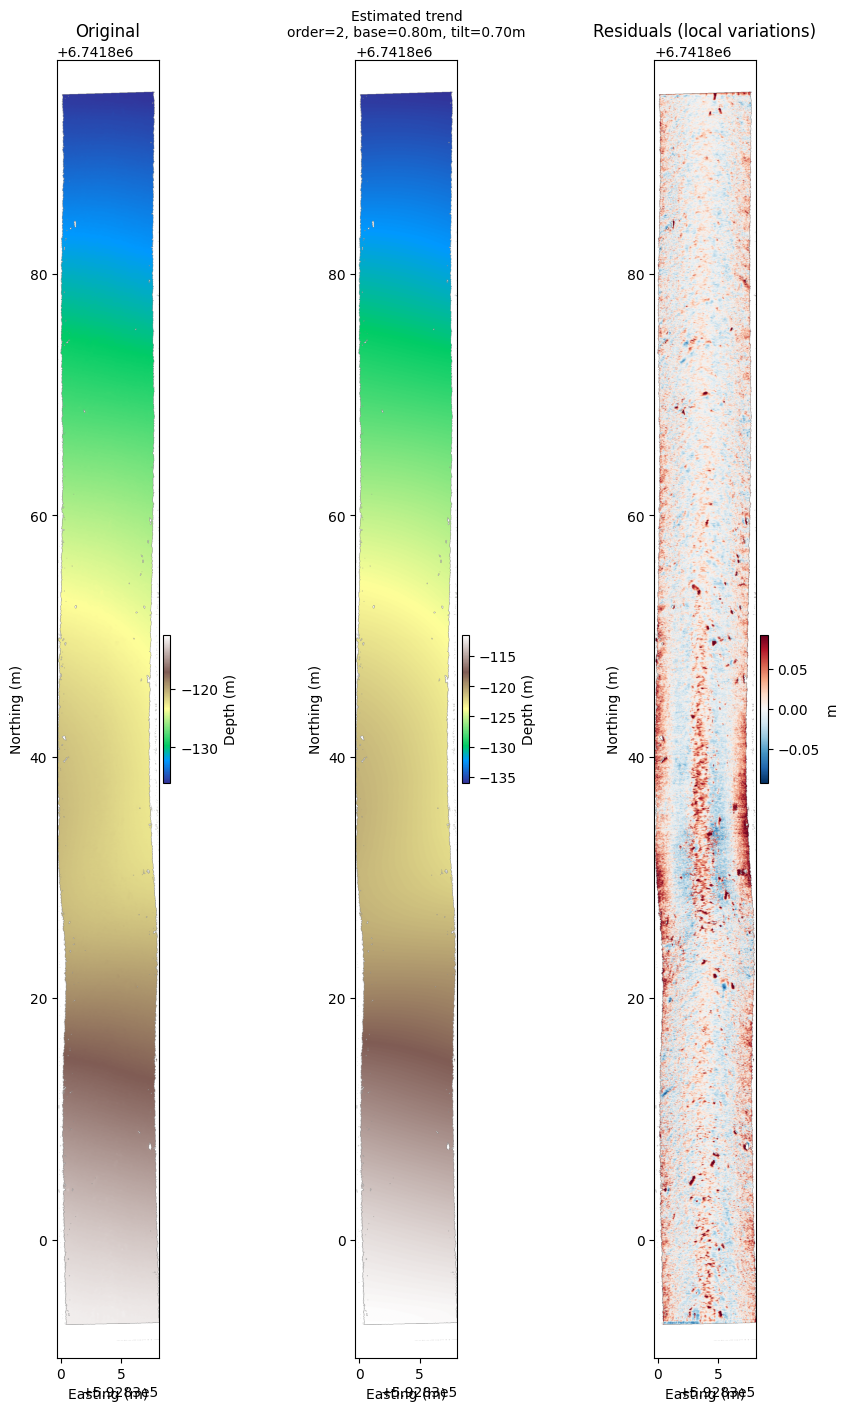

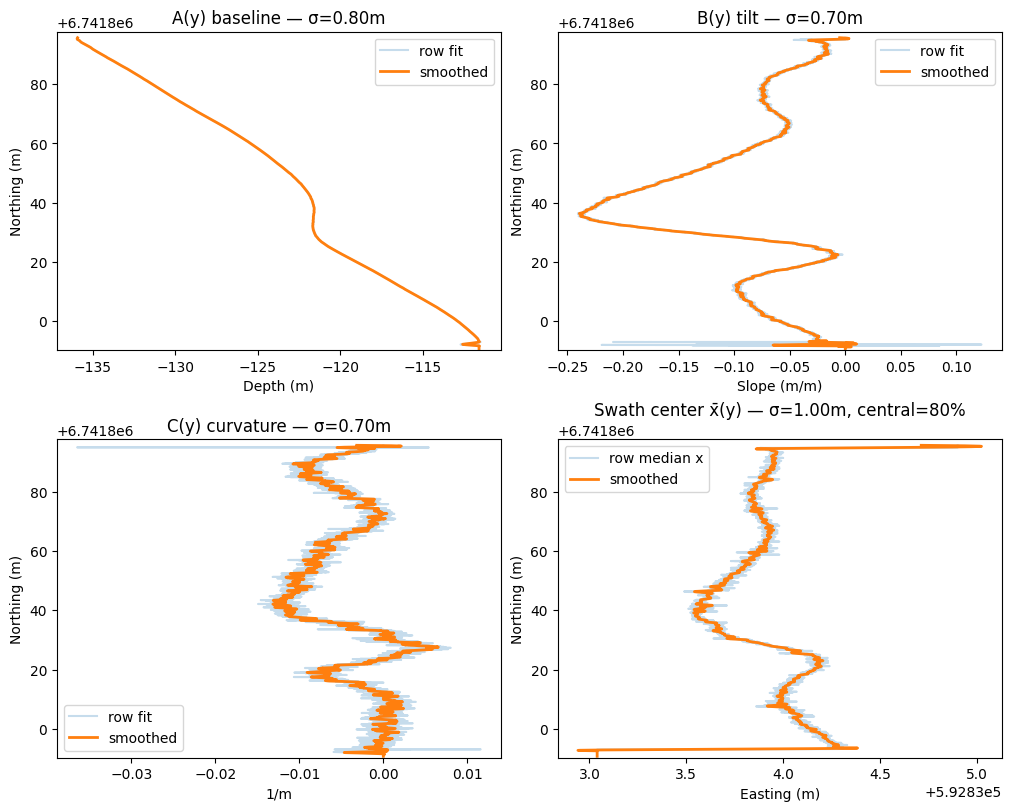

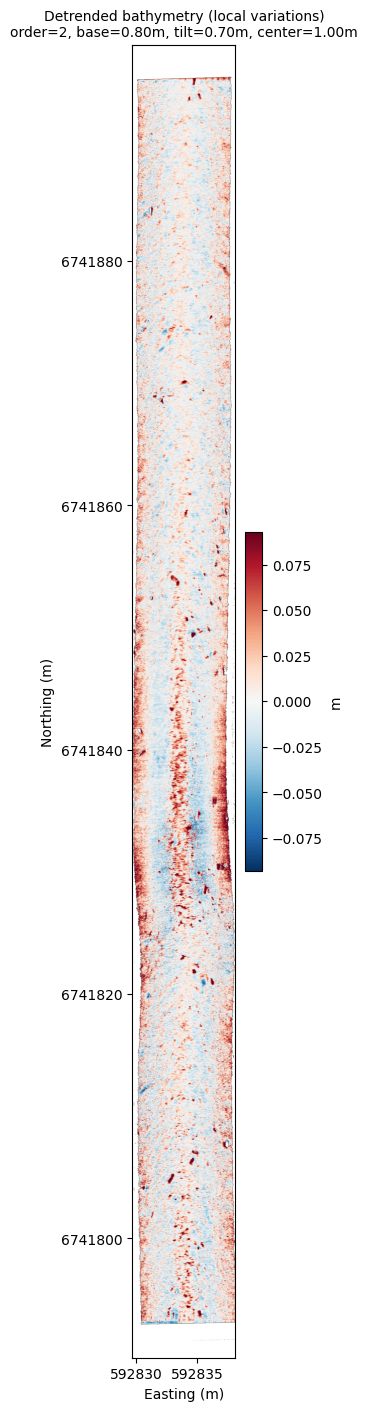

In [11]:
# Cell 2: load + detrend + show all three figures
mb = (
    MBESDetrender(tif_path)
    .load()
    .detrend(
        order_x=3,
        smooth_baseline_m=0.80,
        smooth_tilt_m=0.70,
        smooth_center_m=1.0,
        robust=True,
        central_frac=0.8,
    )
)
_ = mb.plot_all()  # triptych + components + residual heatmap

In [4]:
# mb = (
#     MBESDetrender(tif_path)
#     .load()
#     .detrend(
#         order_x=3,
#         smooth_baseline_m=0.80,
#         smooth_tilt_m=0.70,
#         smooth_center_m=1.0,
#         robust=True,
#         central_frac=0.8,
#     )
# )
# mb.plot_triptych(figsize=(9, 14), equal_aspect=True)

## Option 2: NED coordinates (local frame, relative to origin)
Plots will show coordinates relative to the NED origin from config

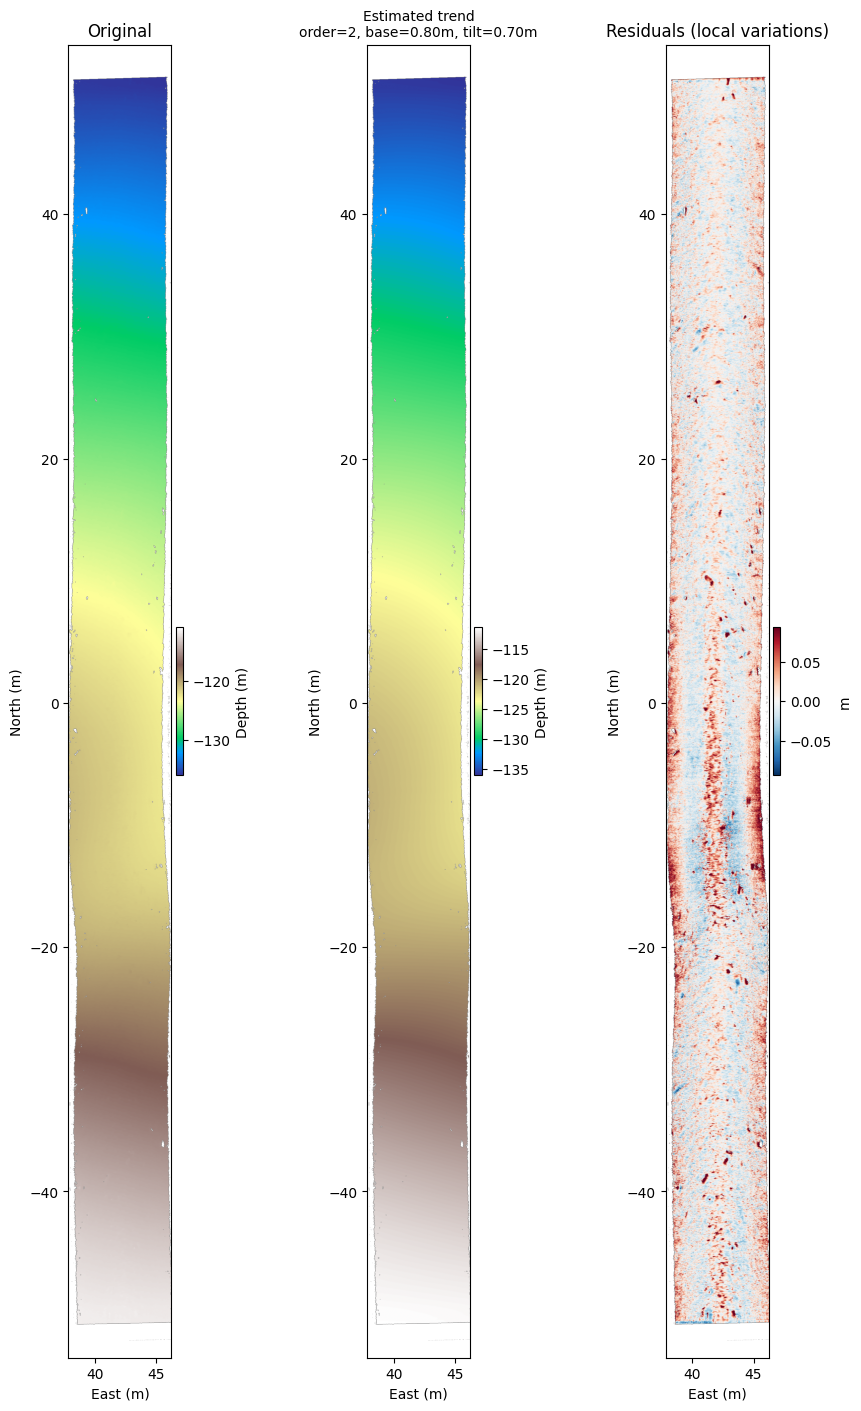

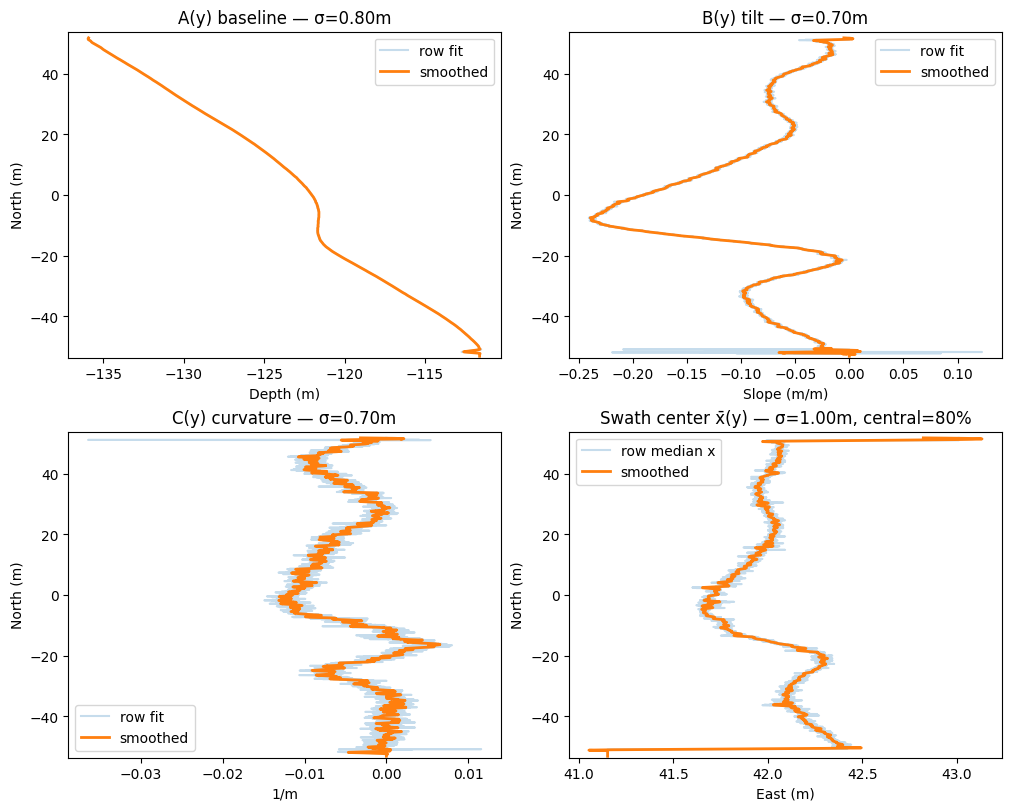

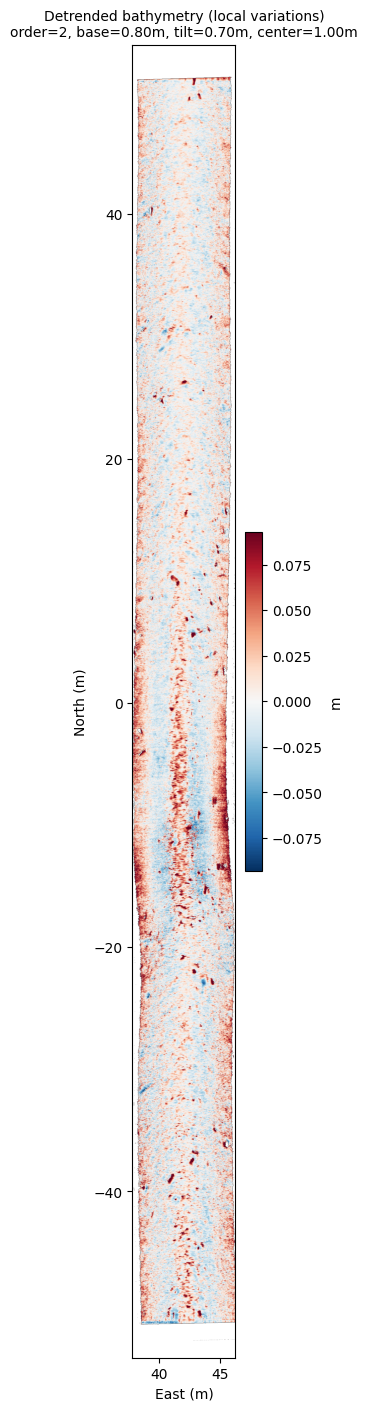

In [10]:
# Use NED coordinate system with origin from config
mb_ned = (
    MBESDetrender(
        tif_path,
        coord_system="ned",
        ned_origin=(config.LON0, config.LAT0, config.H0),
        epsg_utm=config.EPSG_UTM,
        epsg_geo=config.EPSG_GEOGRAPHIC,
    )
    .load()
    .detrend(
        order_x=3,
        smooth_baseline_m=0.80,
        smooth_tilt_m=0.70,
        smooth_center_m=1.0,
        robust=True,
        central_frac=0.8,
    )
)
_ = mb_ned.plot_all()  # triptych + components + residual heatmap in NED frame

In [18]:
# === Monkey-patch: MBESDetrender.plot_triptych with UHI footprint overlay (BLACK) ===
# Show MBES residuals everywhere, overlay UHI footprint in BLACK
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
import sys
import os
from typing import List, Tuple, Dict

sys.path.append(os.path.abspath("../"))


def pcolormesh_pad(X, Y):
    """Pad arrays for pcolormesh."""
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    """
    Build boundary segments EXACTLY along UHI cell edges (no smoothing).
    Returns:
        seg_xy : (N, 2, 2) array of [[x0,y0],[x1,y1]] for plotting (LineCollection)
        seg_idx: list of ((i0,j0),(i1,j1)) corner-index pairs for loop tracing.
    """
    T, S = mask.shape
    segs_xy = []
    segs_idx = []

    # Vertical internal edges (between columns)
    vdiff = mask[:, 1:] != mask[:, :-1]  # shape (T, S-1)
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Left outer edge (j=0)
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Right outer edge (j=S)
    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Horizontal internal edges (between rows)
    hdiff = mask[1:, :] != mask[:-1, :]  # shape (T-1, S)
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Top outer edge (i=0)
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # Bottom outer edge (i=T)
    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, dtype=float), segs_idx


def _trace_loops_from_segments(segs_idx: List[Tuple[Tuple[int, int], Tuple[int, int]]]):
    """
    Convert corner-index segments into closed loops of corner indices.
    Assumes the boundary graph is composed of closed rings (typical for a mask).
    """
    # Build adjacency (undirected)
    adj: Dict[Tuple[int, int], List[Tuple[int, int]]] = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    # Visit edges
    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops: List[List[Tuple[int, int]]] = []

    while unvisited:
        # Start from any remaining edge
        e = unvisited.pop()
        a, b = tuple(e)
        # Build a loop starting with (a->b)
        loop = [a, b]
        prev, cur = a, b

        while True:
            nbrs = adj[cur]
            # Choose next neighbor that is not the previous vertex
            nxt_candidates = [n for n in nbrs if n != prev]
            if not nxt_candidates:
                break  # open edge (shouldn't happen)
            nxt = nxt_candidates[0]
            # mark edge cur<->nxt visited
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break  # closed

        loops.append(loop)

        # Remove any already-visited edges incident to this loop so the while-loop terminates.
        # (Safeguard when degree>2 surfaces happen.)
        i = 0
        while i < len(loop) - 1:
            edge = frozenset((loop[i], loop[i + 1]))
            unvisited.discard(edge)
            i += 1

    return loops


def _compound_path_from_loops(loops, Xc, Yc) -> Path:
    """Create a matplotlib Compound Path in data coords from corner-index loops."""
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        # Ensure closed
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), Path.LINETO, dtype=Path.code_type)
        codes[0] = Path.MOVETO
        codes[-1] = Path.CLOSEPOLY
        paths.append(Path(verts, codes))
    if len(paths) == 1:
        return paths[0]
    return Path.make_compound_path(*paths)


def _plot_triptych_with_uhi_overlay(
    self,
    cmap_orig="terrain",
    cmap_resid="RdBu_r",
    figsize=(9, 14),
    crop_to_data=True,
    bounds_percentile=99.5,
    margin_frac=0.03,
    equal_aspect=True,
    show=True,
    *,
    uhi_footprint=None,  # (E, N, valid_mask) tuple
):
    assert self.trend is not None, "Run detrend() first."

    # axis labels
    if self.coord_system.lower() == "ned":
        xlabel, ylabel = "East (m)", "North (m)"
    else:
        xlabel, ylabel = "Easting (m)", "Northing (m)"

    # helpers
    def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
        xr = max(1e-12, x_max - x_min)
        yr = max(1e-12, y_max - y_min)
        ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
        ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
        if equal_aspect:
            ax.set_aspect("equal", adjustable="datalim")
            try:
                ax.set_box_aspect(yr / xr)
            except Exception:
                pass

    def _robust_sym_vlim(arr, q=0.98):
        m = np.isfinite(arr)
        if not m.any():
            return (-1, 1)
        lo, hi = np.nanquantile(arr[m], [(1 - q) / 2, 1 - (1 - q) / 2])
        vmax_ = max(abs(lo), abs(hi))
        if not np.isfinite(vmax_) or vmax_ == 0:
            vmax_ = (np.nanstd(arr[m]) or 1.0) * 3
        return (-vmax_, vmax_)

    # figure
    fig, axs = plt.subplots(
        1, 3, figsize=figsize, constrained_layout=True, num="MBES Triptych"
    )

    # Original
    im0 = axs[0].imshow(
        np.ma.masked_invalid(self.data),
        extent=(self.extent[0], self.extent[1], self.extent[2], self.extent[3]),
        origin="upper",
        cmap=cmap_orig,
    )
    axs[0].set_title("Original")
    axs[0].set_xlabel(xlabel)
    axs[0].set_ylabel(ylabel)
    fig.colorbar(im0, ax=axs[0], label="Depth (m)", fraction=0.035, pad=0.02)

    # Trend
    im1 = axs[1].imshow(
        np.ma.masked_invalid(self.trend),
        extent=(self.extent[0], self.extent[1], self.extent[2], self.extent[3]),
        origin="upper",
        cmap=cmap_orig,
    )
    ord_label = (
        2
        if (
            getattr(self, "C_s", None) is not None
            and np.nanmax(np.abs(self.C_s)) > 0.001
        )
        else 1
    )
    axs[1].set_title(
        f"Estimated trend\norder={ord_label}, base={self.smooth_baseline_m:.2f}m, tilt={self.smooth_tilt_m:.2f}m",
        fontsize=10,
    )
    axs[1].set_xlabel(xlabel)
    axs[1].set_ylabel(ylabel)
    fig.colorbar(im1, ax=axs[1], label="Depth (m)", fraction=0.035, pad=0.02)

    # Residuals - SHOW EVERYWHERE
    vmin, vmax = _robust_sym_vlim(self.residuals, q=0.98)
    im2 = axs[2].imshow(
        np.ma.masked_invalid(self.residuals),
        extent=(self.extent[0], self.extent[1], self.extent[2], self.extent[3]),
        origin="upper",
        cmap=cmap_resid,
        vmin=vmin,
        vmax=vmax,
        zorder=1,
    )
    axs[2].set_title("Residuals (local variations)")
    axs[2].set_xlabel(xlabel)
    axs[2].set_ylabel(ylabel)
    fig.colorbar(im2, ax=axs[2], label="m", fraction=0.035, pad=0.02)

    # Crop window
    if crop_to_data and np.isfinite(self.data).any():
        rows, cols = np.where(np.isfinite(self.data))
        p_lo = (100 - bounds_percentile) / 2
        p_hi = 100 - p_lo
        c0 = int(np.percentile(cols, p_lo))
        c1 = int(np.percentile(cols, p_hi))
        r0 = int(np.percentile(rows, p_lo))
        r1 = int(np.percentile(rows, p_hi))
        x_min, x_max = self.x_cols[c0], self.x_cols[c1]
        y_min, y_max = self.y_rows[r1], self.y_rows[r0]
    else:
        x_min, x_max, y_min, y_max = (
            self.extent[0],
            self.extent[1],
            self.extent[2],
            self.extent[3],
        )

    # === OVERLAY UHI FOOTPRINT IN BLACK on top of MBES ===
    if uhi_footprint is not None:
        if isinstance(uhi_footprint, tuple) and len(uhi_footprint) == 3:
            E, N, valid_mask = uhi_footprint

            # Build pixel-perfect boundary path
            Xc, Yc = pcolormesh_pad(E, N)
            segs_xy, segs_idx = _boundary_segments_from_mask(valid_mask, Xc, Yc)
            loops = _trace_loops_from_segments(segs_idx)
            comp_path = _compound_path_from_loops(loops, Xc, Yc)

            # Fill the UHI footprint with BLACK (on top of MBES)
            black_patch = PathPatch(
                comp_path,
                transform=axs[2].transData,
                facecolor="black",
                edgecolor="none",
                zorder=10,
                alpha=1.0,
            )
            axs[2].add_patch(black_patch)
        else:
            raise TypeError("uhi_footprint must be (E, N, valid_mask) tuple.")

    # apply limits
    for ax in axs:
        _pad_limits(
            ax,
            x_min,
            x_max,
            y_min,
            y_max,
            pad_frac=margin_frac,
            equal_aspect=equal_aspect,
        )

    if show:
        plt.show(block=False)
    return fig


# Apply monkey-patch
try:
    MBESDetrender
except NameError:
    from utils.other.detrend_mbes import MBESDetrender
MBESDetrender.plot_triptych = _plot_triptych_with_uhi_overlay

print("✅ Monkey-patch applied successfully!")

✅ Monkey-patch applied successfully!


In [19]:
%matplotlib qt

In [20]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Make sure we can import utils and georef
sys.path.append(os.path.abspath("../"))

from utils.other.detrend_mbes import MBESDetrender  # your patched class
from utils.gref_pipeline import georef  # Import georef module
from utils.gref_pipeline.georef import _ecef_to_ned_arrays  # convert to NED
from gref_pipeline import config  # Import config properly


# Helper function to build valid mask
def build_full_valid_mask(X_ecef, Y_ecef, Z_ecef, R, G, B):
    """Check if all coordinates and RGB values are finite."""
    coords_valid = np.isfinite(X_ecef) & np.isfinite(Y_ecef) & np.isfinite(Z_ecef)
    rgb_valid = np.isfinite(R) & np.isfinite(G) & np.isfinite(B)
    return coords_valid & rgb_valid


print("📂 Loading UHI transect data...")
# 1) Load transect and select specific UHI files
transect = georef.load_transect(config.OUTPUT_FOLDER)
cube = transect.select_files(
    [
        "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)

# Define track range
track_start = 3039
track_end = 4029

print(f"📊 Extracting tracks {track_start} to {track_end}...")
# 2) Extract ECEF coordinates and RGB values for the chosen track range
X_ecef = cube.X_ecef[track_start:track_end, :]
Y_ecef = cube.Y_ecef[track_start:track_end, :]
Z_ecef = cube.Z_ecef[track_start:track_end, :]
R = cube.R[track_start:track_end, :]
G = cube.G[track_start:track_end, :]
B = cube.B[track_start:track_end, :]

# 3) Build the boolean mask of valid UHI pixels (all finite)
full_valid = build_full_valid_mask(X_ecef, Y_ecef, Z_ecef, R, G, B)

# 4) Convert UHI ECEF coordinates to local NED East/North (origin from config)
lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
N, E, _ = _ecef_to_ned_arrays(X_ecef, Y_ecef, Z_ecef, lat0, lon0, h0)

# Summary of UHI footprint
print(f"✅ UHI Footprint: E shape={E.shape}, N shape={N.shape}")
print(
    f"   Valid pixels: {full_valid.sum():,} / {full_valid.size:,} ({100*full_valid.mean():.1f}%)"
)

print("\n🗺️  Loading and detrending MBES data in NED frame...")
# 5) Detrend your MBES data and work in NED
mb_ned = (
    MBESDetrender(
        config.MBES_GEOTIFF,
        coord_system="ned",
        ned_origin=(config.LON0, config.LAT0, config.H0),
        epsg_utm=config.EPSG_UTM,
        epsg_geo=config.EPSG_GEOGRAPHIC,
    )
    .load()
    .detrend(
        order_x=3,
        smooth_baseline_m=0.80,
        smooth_tilt_m=0.70,
        smooth_center_m=1.0,
        robust=True,
        central_frac=0.8,
    )
)

print("\n🎨 Plotting MBES triptych with UHI footprint overlay...")
# 6) Finally, call plot_triptych with the footprint tuple (E, N, full_valid)
#    This will fill the UHI footprint region on the residual panel in black
fig = mb_ned.plot_triptych(uhi_footprint=(E, N, full_valid), show=True)
print("✅ Done!")

📂 Loading UHI transect data...
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
📊 Extracting tracks 3039 to 4029...
✅ UHI Footprint: E shape=(990, 968), N shape=(990, 968)
   Valid pixels: 958,320 / 958,320 (100.0%)

🗺️  Loading and detrending MBES data in NED frame...
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
📊 Extracting tracks 3039 to 4029...
✅ UHI Footprint: E shape=(990, 968), N shape=(990, 968)
   Valid pixels: 958,320 / 958,320 (100.0%)

🗺️  Loading and detrending MBES data in NED frame...

🎨 Plotting MBES triptych with UHI footprint overlay...

🎨 Plotting MBES triptych with UHI footprint overlay...
✅ Done!
✅ Done!


uses a autotuner to find optimal parameters

### Autotuner Parameter Guide

**Problem:** Default autotuner does 162 iterations (round 1) + 625 iterations (round 2) = **787 total!**

**Solutions to reduce iterations:**

1. **Set `max_rounds=1`** - Skip the refinement round
   - Round 1 only: **162 iterations** (coarse grid search)
   
2. **Use `allowed_orders=(3,)`** - Fix the polynomial order
   - Reduces round 1 to **81 iterations** (only order 3)
   - Reduces round 2 to **625 iterations** (if used)
   
3. **Increase `row_stride` and `col_stride`**
   - Default: `(4, 4)` - samples every 4th pixel
   - Try: `(8, 8)` or `(10, 10)` - **faster evaluation** (same # iterations, but quicker)
   
4. **Combine strategies** for maximum speed:
   ```python
   # FAST MODE: ~81 iterations total
   tuner = AutoTuneMBES(mb_ned, 
                        allowed_orders=(3,),      # Fix order
                        row_stride=8, col_stride=8,  # Coarser sampling
                        ...)
   best = tuner.fit(max_rounds=1)  # Skip refinement
   ```

In [ ]:
# FAST MODE: Only ~81 iterations instead of 787!
tuner_fast = AutoTuneMBES(
    mb_ned,
    allowed_orders=(3,),  # Fix order to 3 (halves iterations)
    row_stride=8,  # Coarser sampling (faster per iteration)
    col_stride=8,
    weights=ScoreWeights(
        w_rstd=1.0,
        w_banding=1.0,
        w_edge_bias=3.0,
        w_x_slope=1.0,
        w_rough_B=0.3,
        w_rough_X=0.3,
    ),
    log_csv="mbes_tuning_log_fast.csv",
    progress_every=10,
)

best_fast = tuner_fast.fit(max_rounds=1, resume=True)  # Only coarse search
mb_best_fast = tuner_fast.apply_best_and_plot()

**SLOW MODE** (for reference - 787 iterations total):

In [ ]:
# Cell 3: optional autotune, then plot with best params
tuner = AutoTuneMBES(
    mb_ned,
    allowed_orders=(2, 3),
    row_stride=4,
    col_stride=4,  # 1,1 for max accuracy
    weights=ScoreWeights(
        w_rstd=1.0,
        w_banding=1.0,
        w_edge_bias=3.0,
        w_x_slope=1.0,
        w_rough_B=0.3,
        w_rough_X=0.3,
    ),
    log_csv="mbes_tuning_log.csv",
    progress_every=5,
)

best = tuner.fit(max_rounds=2, resume=True)
mb_best = tuner.apply_best_and_plot()

[resume] loaded 660 trials from c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\notebooks\mbes_tuning_log.csv
Coarse best: {'order': 2, 'central_frac': 0.7, 'baseline_m': 0.357, 'tilt_m': 4.05, 'center_m': 1.3439999999999999} -> 8.867409 (0.0s)
Round 1: 625 neighbors
   ... 5/625 done (best=8.8674)
   ... 5/625 done (best=8.8674)
   ... 10/625 done (best=8.8674)
   ... 10/625 done (best=8.8674)
  better: {'order': 2, 'central_frac': 0.6, 'baseline_m': 0.24989999999999998, 'tilt_m': 4.05, 'center_m': 0.9407999999999999}  8.382118
  better: {'order': 2, 'central_frac': 0.6, 'baseline_m': 0.24989999999999998, 'tilt_m': 4.05, 'center_m': 0.9407999999999999}  8.382118
  better: {'order': 2, 'central_frac': 0.6, 'baseline_m': 0.24989999999999998, 'tilt_m': 4.05, 'center_m': 1.3439999999999999}  8.380857
  better: {'order': 2, 'central_frac': 0.6, 'baseline_m': 0.24989999999999998, 'tilt_m': 4.05, 'center_m': 1.34399999999

In [ ]:
# tuner = AutoTuneMBES(
#     mb,
#     allowed_orders=(2, 3),
#     row_stride=4,
#     col_stride=4,
#     weights=ScoreWeights(),
#     log_csv="mbes_tuning_log.csv",
# )
# best = tuner.fit(max_rounds=2, resume=True)
# mb_best = tuner.apply_best_and_plot()

c:\conda_envs\my_env\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


... tried 35/162 (last 26.3390)
